# 1. Prepare data with Synth

In [1]:
import pandas as pd
import json
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd


2025-11-08 20:00:26.705071: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762632026.911440      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762632026.962901      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
import pandas as pd
df = pd.read_excel('/kaggle/input/hackathon/dataset_QA (1).xlsx', engine='openpyxl')  # requires openpyxl
df_out = df[['Khách hàng hỏi','Nhân viên trả lời','Cột 1']]# cot 1 la negative, nhan vien trl la positive
print(df_out.head(2))
df_out.to_csv('dataset_QA.csv', index=False,header=False ,encoding='utf-8')

                                      Khách hàng hỏi  \
0  Tôi sắp đến Đà Nẵng và muốn tìm vài món ăn đặc...   
1  Còn Bánh xèo thì sao? Tôi nghe nói có nhiều lo...   

                                   Nhân viên trả lời  \
0  Chào mừng bạn đến Đà Nẵng! Về hải sản tươi sốn...   
1  Đúng vậy. Bánh xèo Đà Nẵng thường có kích thướ...   

                                               Cột 1  
0  Tôi nghĩ bạn nên thử một quán cà phê mới, tôi ...  
1  Nhưng Bạn có thử bánh mì kẹp không? Tôi nghĩ b...  


# 2. Train

## Train test split

In [3]:

# Shuffle the dataset
df = pd.read_csv("/kaggle/working/dataset_QA.csv", encoding="utf-8-sig")
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Split into train, validation, and test sets (e.g., 80% train, 10% validation, 10% test)
train_frac = 0.8
valid_frac = 0.1
test_frac = 0.1

# define train and validation size
train_size = int(train_frac * len(df))
valid_size = int(valid_frac * len(df))

# create train, validation, and test datasets
df_train = df[:train_size]
df_valid = df[train_size:train_size + valid_size]
df_test = df[train_size + valid_size:]

In [4]:
df_valid.head(2)

,"Tôi sắp đến Đà Nẵng và muốn tìm vài món ăn đặc trưng ở đó, đặc biệt là hải sản tươi sống. Bạn có thể gợi ý cho tôi không?","Chào mừng bạn đến Đà Nẵng! Về hải sản tươi sống, bạn nhất định phải thử ""Hải sản Mỹ Hạnh"" hoặc ""Bà Thôi"". Còn về món đặc trưng, bạn có thể thử Mì Quảng và Bánh xèo nhé.","Tôi nghĩ bạn nên thử một quán cà phê mới, tôi thường hay đến đó."
329,"Tôi muốn tìm một món ăn chính, có thịt và rau,...",Chào bạn! Bạn có thể thử Cơm gà Hội An. Dù có ...,"Bạn biết không, tôi vừa mua cây cảnh mới và nó..."
330,Vậy còn món tráng miệng nào có thể tìm thấy ở ...,"Để tráng miệng, bạn có thể tìm Bánh flan. Món ...","À, Bạn có thử bánh mì kẹp mà tôi hay ăn không?..."


In [5]:
# Convert the pandas DataFrames back to Hugging Face Datasets
from datasets import Dataset, DatasetDict

train_ds = Dataset.from_pandas(df_train)
valid_ds = Dataset.from_pandas(df_valid)
test_ds = Dataset.from_pandas(df_test)

# Combine into a DatasetDict
dataset = DatasetDict({
    'train': train_ds,
    'validation': valid_ds,
    'test': test_ds
})


# Finetune

In [6]:
# !pip install -U -q sentence-transformers git+https://github.com/huggingface/transformers@v4.56.0-Embedding-Gemma-preview
# !pip install -U transformers

In [7]:
import torch
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import pipeline

device = "cuda" if torch.cuda.is_available() else "cpu"
task_name = "STS"



In [8]:
!git config --global credential.helper store

# Login into Hugging Face Hub
from huggingface_hub import login
login()

In [9]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
model.save("custom-embedding-model") #/kaggle/working/custom-embedding-model

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Device: cuda
SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)
Total parameters: 22713216


🔹 Cosine(anchor, positive): 0.6972
🔸 Cosine(anchor, negative): 0.5837
✅ Độ chênh lệch trung bình: 0.1135



Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
329,0.234500
658,0.045800



🌟 Epoch 1 kết thúc — đánh giá...
🔹 Cosine(anchor, positive): 0.6258
🔸 Cosine(anchor, negative): 0.0455
✅ Độ chênh lệch trung bình: 0.5803


🌟 Epoch 2 kết thúc — đánh giá...
🔹 Cosine(anchor, positive): 0.6830
🔸 Cosine(anchor, negative): -0.0201
✅ Độ chênh lệch trung bình: 0.7031


🌟 Epoch 3 kết thúc — đánh giá...
🔹 Cosine(anchor, positive): 0.6790
🔸 Cosine(anchor, negative): -0.0368
✅ Độ chênh lệch trung bình: 0.7158


🌟 Epoch 4 kết thúc — đánh giá...
🔹 Cosine(anchor, positive): 0.6733
🔸 Cosine(anchor, negative): -0.0660
✅ Độ chênh lệch trung bình: 0.7393


🌟 Epoch 5 kết thúc — đánh giá...
🔹 Cosine(anchor, positive): 0.6851
🔸 Cosine(anchor, negative): -0.0733
✅ Độ chênh lệch trung bình: 0.7583

🔹 Cosine(anchor, positive): 0.6851
🔸 Cosine(anchor, negative): -0.0733
✅ Độ chênh lệch trung bình: 0.7583



/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


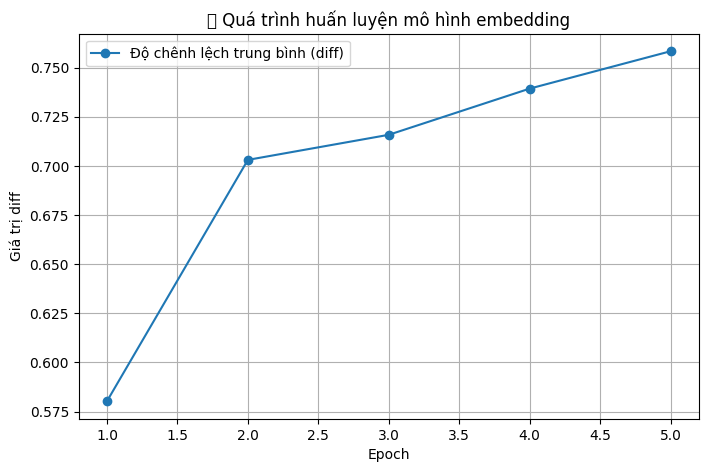

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


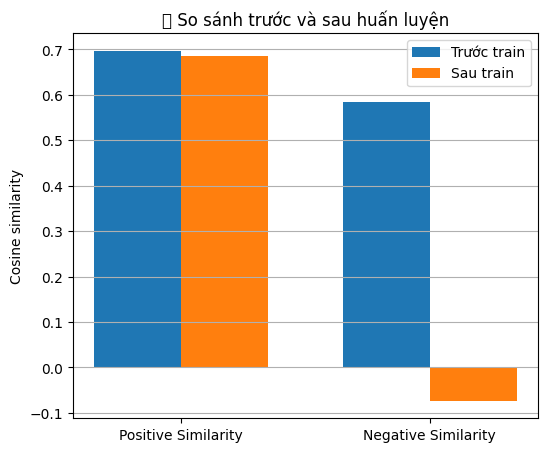

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer, SentenceTransformerTrainer, SentenceTransformerTrainingArguments
from sentence_transformers.losses import MultipleNegativesRankingLoss
from transformers import TrainerCallback
import torch


# ==============================================
# 0️⃣ CẤU HÌNH DEVICE
# ==============================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# ==============================================
# 1️⃣ LOAD MÔ HÌNH TỪ FILE GGUF
# ==============================================
model_path = "custom-embedding-model"

# Nếu sentence-transformers >=2.2, có thể load trực tiếp
model = SentenceTransformer(model_path)
model.to(device)
print(model)
print("Total parameters:", sum([p.numel() for p in model.parameters()]))

# ==============================================
# 2️⃣ HÀM ĐÁNH GIÁ embedding
# ==============================================
def evaluate_embedding(model, df_eval):
    anchor_emb = model.encode(df_eval["Khách hàng hỏi"].tolist(), convert_to_numpy=True, show_progress_bar=False)
    pos_emb = model.encode(df_eval["Nhân viên trả lời"].tolist(), convert_to_numpy=True, show_progress_bar=False)
    neg_emb = model.encode(df_eval["Cột 1"].tolist(), convert_to_numpy=True, show_progress_bar=False)

    sim_pos = np.diag(cosine_similarity(anchor_emb, pos_emb))
    sim_neg = np.diag(cosine_similarity(anchor_emb, neg_emb))
    avg_diff = np.mean(sim_pos - sim_neg)

    print(f"🔹 Cosine(anchor, positive): {sim_pos.mean():.4f}")
    print(f"🔸 Cosine(anchor, negative): {sim_neg.mean():.4f}")
    print(f"✅ Độ chênh lệch trung bình: {avg_diff:.4f}\n")

    return {"pos": sim_pos.mean(), "neg": sim_neg.mean(), "diff": avg_diff}

# ==============================================
# 3️⃣ CALLBACK lưu kết quả
# ==============================================
import torch
import numpy as np

class EvalCallback(TrainerCallback):
    def __init__(self, eval_func, eval_data):
        self.eval_func = eval_func
        self.eval_data = eval_data
        self.history = []
        self._model = None

    def on_train_begin(self, args, state, control, **kwargs):
        self._model = kwargs.get("model", self._model)

    def on_epoch_end(self, args, state, control, **kwargs):
        print(f"\n🌟 Epoch {state.epoch:.0f} kết thúc — đánh giá...")
        model = kwargs.get("model", self._model)
        if model is None:
            print("⚠️ Không tìm thấy model trong callback. Bỏ qua evaluate.")
            return

        # --- Đánh giá embedding ---
        scores = self.eval_func(model, self.eval_data)

        # --- Đo mức sử dụng GPU ---
        if torch.cuda.is_available():
            mem_used = torch.cuda.memory_allocated() / (1024**2)  # MB
        else:
            mem_used = 0

        self.history.append({
            "epoch": state.epoch,
            "gpu_mem_mb": mem_used,
            **scores
        })


# ==============================================
# 4️⃣ ĐÁNH GIÁ TRƯỚC HUẤN LUYỆN
# ==============================================
before_train = evaluate_embedding(model, df_out)

# ==============================================
# 5️⃣ CẤU HÌNH HUẤN LUYỆN
# ==============================================
loss = MultipleNegativesRankingLoss(model)

training_args = SentenceTransformerTrainingArguments(
    output_dir="custom-embedding-model",
    num_train_epochs=5,
    per_device_train_batch_size=1,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    logging_steps=len(dataset["train"]),
    report_to="none"
)

callback = EvalCallback(evaluate_embedding, df_out)

trainer = SentenceTransformerTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    loss=loss,
    callbacks=[callback]
)

trainer.train()

# ==============================================
# 6️⃣ ĐÁNH GIÁ SAU HUẤN LUYỆN
# ==============================================
after_train = evaluate_embedding(model, df_out)

# ---- VẼ BIỂU ĐỒ
epochs = [d["epoch"] for d in callback.history]
diffs = [d["diff"] for d in callback.history]

plt.figure(figsize=(8,5))
plt.plot(epochs, diffs, marker='o', label="Độ chênh lệch trung bình (diff)")
plt.xlabel("Epoch")
plt.ylabel("Giá trị diff")
plt.title("📈 Quá trình huấn luyện mô hình embedding")
plt.legend()
plt.grid(True)
plt.show()

labels = ["Positive Similarity", "Negative Similarity"]
before_vals = [before_train["pos"], before_train["neg"]]
after_vals = [after_train["pos"], after_train["neg"]]

x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(6,5))
plt.bar(x - width/2, before_vals, width, label="Trước train")
plt.bar(x + width/2, after_vals, width, label="Sau train")
plt.xticks(x, labels)
plt.ylabel("Cosine similarity")
plt.title("🔍 So sánh trước và sau huấn luyện")
plt.legend()
plt.grid(axis="y")
plt.show()


/tmp/ipykernel_48/1326222086.py:33: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from current font.
  fig.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


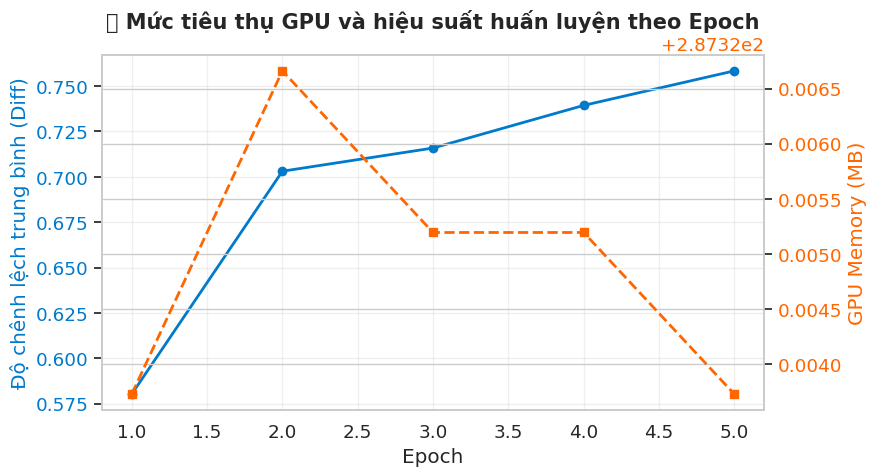

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)

# =====================================
# 🔹 Biểu đồ mức tiêu thụ GPU
# =====================================
epochs = [d["epoch"] for d in callback.history]
gpu_mem = [d["gpu_mem_mb"] for d in callback.history]
diffs = [d["diff"] for d in callback.history]

fig, ax1 = plt.subplots(figsize=(9,5))

color1 = "#007ACC"
color2 = "#FF6600"

# Biểu đồ diff
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Độ chênh lệch trung bình (Diff)", color=color1)
ax1.plot(epochs, diffs, marker='o', linewidth=2, color=color1, label="Diff")
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(alpha=0.3)

# Biểu đồ GPU memory (trục phụ)
ax2 = ax1.twinx()
ax2.set_ylabel("GPU Memory (MB)", color=color2)
ax2.plot(epochs, gpu_mem, marker='s', linewidth=2, linestyle='--', color=color2, label="GPU Memory")
ax2.tick_params(axis='y', labelcolor=color2)

# Tiêu đề và chú thích
plt.title("💻 Mức tiêu thụ GPU và hiệu suất huấn luyện theo Epoch", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()


In [12]:
plt.savefig("/kaggle/working/gpu_usage_plot.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [13]:
save_path = "saved-embedding-model"
trainer.save_model(save_path)

print(f"📂 Mô hình đã được lưu tại: {save_path}")

📂 Mô hình đã được lưu tại: saved-embedding-model


In [14]:
# def embedding1(model, df_eval):
#     anchor_emb = model.encode(df_eval["Khách hàng hỏi"].tolist(), convert_to_numpy=True, show_progress_bar=False)
#     pos_emb = model.encode(df_eval["Nhân viên trả lời"].tolist(), convert_to_numpy=True, show_progress_bar=False)
#     neg_emb = model.encode(df_eval["Cột 1"].tolist(), convert_to_numpy=True, show_progress_bar=False)

#     return anchor_emb, pos_emb, neg_emb
# from sentence_transformers import SentenceTransformer
# model1 = SentenceTransformer("saved-embedding-model")
# anchor_emb, pos_emb, neg_emb = embedding1(model1, df_out)


In [15]:
# print(len(anchor_emb[1]))


In [16]:
import zipfile
import os
from IPython.display import FileLink

def zip_dir(directory = os.curdir, file_name = 'directory.zip'):
    """
    zip all the files in a directory
    
    Parameters
    _____
    directory: str
        directory needs to be zipped, defualt is current working directory
        
    file_name: str
        the name of the zipped file (including .zip), default is 'directory.zip'
        
    Returns
    _____
    Creates a hyperlink, which can be used to download the zip file)
    """
    os.chdir(directory)
    zip_ref = zipfile.ZipFile(file_name, mode='w')
    for folder, _, files in os.walk(directory):
        for file in files:
            if file_name in file:
                pass
            else:
                zip_ref.write(os.path.join(folder, file))

    return FileLink(file_name)
zip_dir()

/kaggle/working/directory.zip